In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
dados_path = Path("dados")

arquivos = [
    "todos_1cont_100users.csv",
    "todos_1cont_400users.csv",
    "todos_1cont_720users.csv",
    "todos_2cont_100users.csv",
    "todos_2cont_400users.csv",
    "todos_2cont_720users.csv",
    "todos_3cont_100users.csv",
    "todos_3cont_400users.csv",
    "todos_3cont_720users.csv",
]

In [22]:
registros = []

for arquivo in arquivos:
    df = pd.read_csv(dados_path / arquivo)
    agregado = df[df["Name"] == "Aggregated"].iloc[0]

    partes = arquivo.replace(".csv", "").split("_")
    containers = int(partes[1].replace("cont", ""))
    usuarios = int(partes[2].replace("users", ""))

    registros.append({
        "containers": containers,
        "usuarios": usuarios,
        "tempo_medio_resposta": agregado["Average Response Time"],
        "mediana_resposta": agregado["Median Response Time"],
        "rps": agregado["Requests/s"],
        "falhas": agregado["Failure Count"],
        "requisicoes": agregado["Request Count"]
    })

resultado = pd.DataFrame(registros)
resultado

,containers,usuarios,tempo_medio_resposta,mediana_resposta,rps,falhas,requisicoes
0,1,100,85.038751,73.0,46.337761,0,4385
1,1,400,238.399372,140.0,175.919554,0,13690
2,1,720,658.078415,530.0,262.554724,681,26000
3,2,100,93.528778,78.0,45.917771,0,4058
4,2,400,258.423222,120.0,174.418391,0,11431
5,2,720,600.852828,400.0,272.332798,5085,55178
6,3,100,106.972071,85.0,45.148708,0,3994
7,3,400,303.841177,130.0,171.159725,0,19591
8,3,720,523.117581,210.0,279.067485,10818,38948


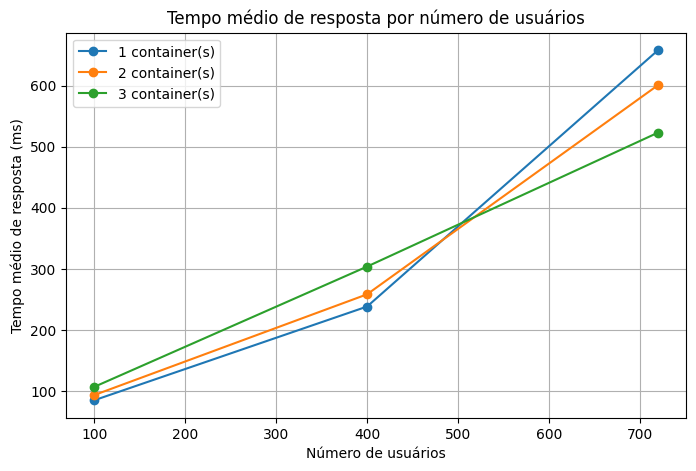

In [23]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = resultado[resultado["containers"] == containers].sort_values("usuarios")
    plt.plot(dados["usuarios"], dados["tempo_medio_resposta"], marker="o", label=f"{containers} container(s)")

plt.xlabel("Número de usuários")
plt.ylabel("Tempo médio de resposta (ms)")
plt.title("Tempo médio de resposta por número de usuários")
plt.legend()
plt.grid(True)
plt.show()

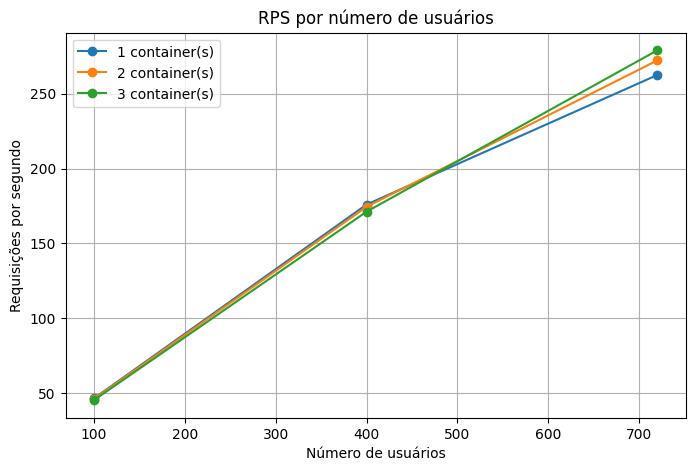

In [6]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = resultado[resultado["containers"] == containers].sort_values("usuarios")
    plt.plot(dados["usuarios"], dados["rps"], marker="o", label=f"{containers} container(s)")

plt.xlabel("Número de usuários")
plt.ylabel("Requisições por segundo")
plt.title("RPS por número de usuários")
plt.legend()
plt.grid(True)
plt.show()

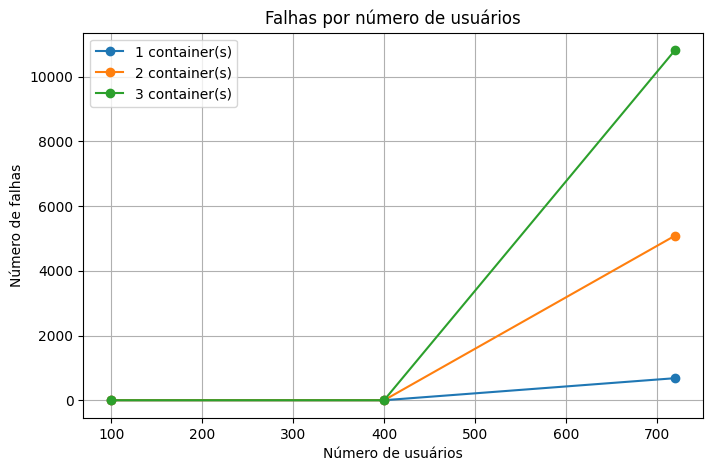

In [7]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = resultado[resultado["containers"] == containers].sort_values("usuarios")
    plt.plot(dados["usuarios"], dados["falhas"], marker="o", label=f"{containers} container(s)")

plt.xlabel("Número de usuários")
plt.ylabel("Número de falhas")
plt.title("Falhas por número de usuários")
plt.legend()
plt.grid(True)
plt.show()

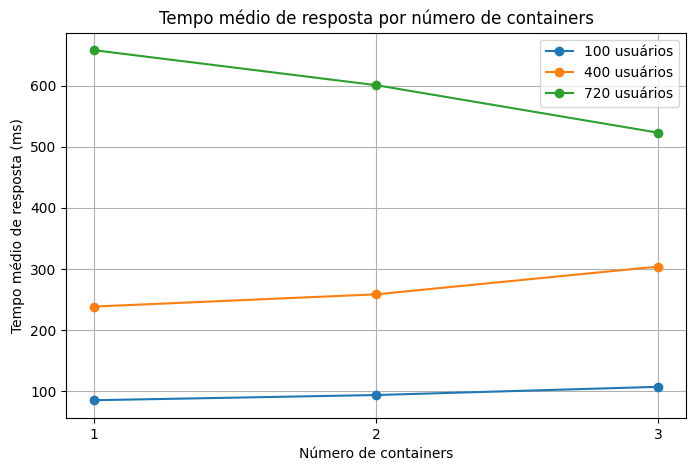

In [8]:
plt.figure(figsize=(8, 5))

for usuarios in sorted(resultado["usuarios"].unique()):
    dados = resultado[resultado["usuarios"] == usuarios].sort_values("containers")
    plt.plot(dados["containers"], dados["tempo_medio_resposta"], marker="o", label=f"{usuarios} usuários")

plt.xlabel("Número de containers")
plt.ylabel("Tempo médio de resposta (ms)")
plt.title("Tempo médio de resposta por número de containers")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

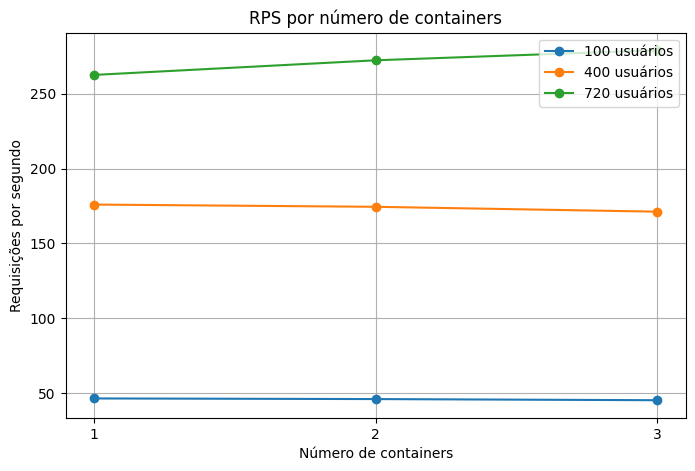

In [9]:
plt.figure(figsize=(8, 5))

for usuarios in sorted(resultado["usuarios"].unique()):
    dados = resultado[resultado["usuarios"] == usuarios].sort_values("containers")
    plt.plot(dados["containers"], dados["rps"], marker="o", label=f"{usuarios} usuários")

plt.xlabel("Número de containers")
plt.ylabel("Requisições por segundo")
plt.title("RPS por número de containers")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

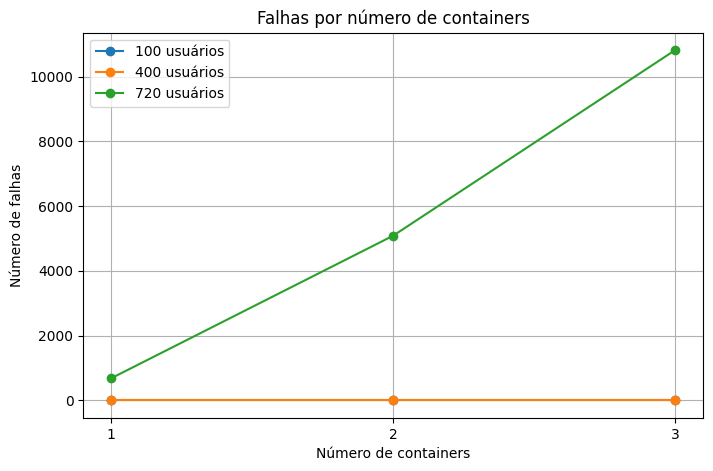

In [10]:
plt.figure(figsize=(8, 5))

for usuarios in sorted(resultado["usuarios"].unique()):
    dados = resultado[resultado["usuarios"] == usuarios].sort_values("containers")
    plt.plot(dados["containers"], dados["falhas"], marker="o", label=f"{usuarios} usuários")

plt.xlabel("Número de containers")
plt.ylabel("Número de falhas")
plt.title("Falhas por número de containers")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

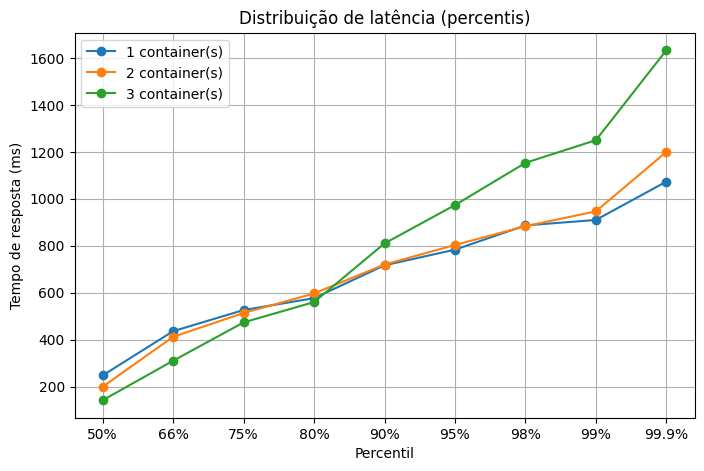

In [18]:
percentis = ["50%", "66%", "75%", "80%", "90%", "95%", "98%", "99%", "99.9%"]

plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    df_plot = []
    
    for usuarios in [100, 400, 720]: # Corrigido de 800 para 720
        # Corrigida a string para bater com o nome real dos arquivos
        arquivo = f"todos_{containers}cont_{usuarios}users.csv"
        
        df = pd.read_csv(dados_path / arquivo)
        agg = df[df["Name"] == "Aggregated"].iloc[0]
        valores = [agg[p] for p in percentis]
        df_plot.append(valores)
    
    media = pd.DataFrame(df_plot).mean()
    plt.plot(percentis, media, marker="o", label=f"{containers} container(s)")

plt.xlabel("Percentil")
plt.ylabel("Tempo de resposta (ms)")
plt.title("Distribuição de latência (percentis)")
plt.legend()
plt.grid(True)
plt.show()

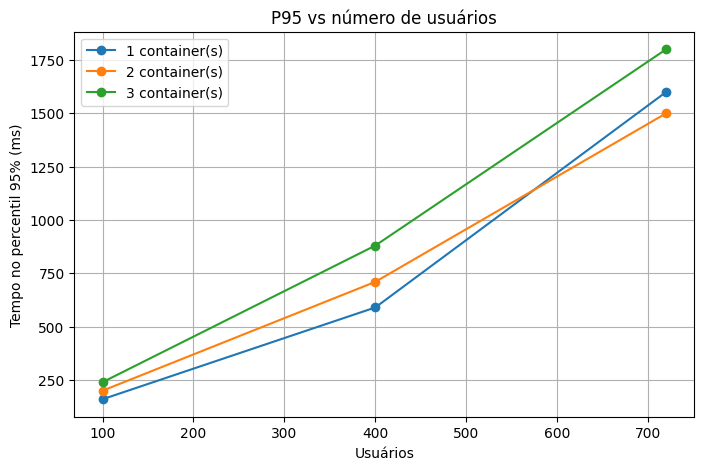

In [20]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = []
    
    for usuarios in [100, 400, 720]: # Corrigido para 720
        # Corrigido o padrão do nome do arquivo
        arquivo = f"todos_{containers}cont_{usuarios}users.csv"
        
        df = pd.read_csv(dados_path / arquivo)
        agg = df[df["Name"] == "Aggregated"].iloc[0]
        dados.append(agg["95%"])
    
    # Corrigido o eixo X para 720 também
    plt.plot([100, 400, 720], dados, marker="o", label=f"{containers} container(s)")

plt.xlabel("Usuários")
plt.ylabel("Tempo no percentil 95% (ms)")
plt.title("P95 vs número de usuários")
plt.legend()
plt.grid(True)
plt.show()

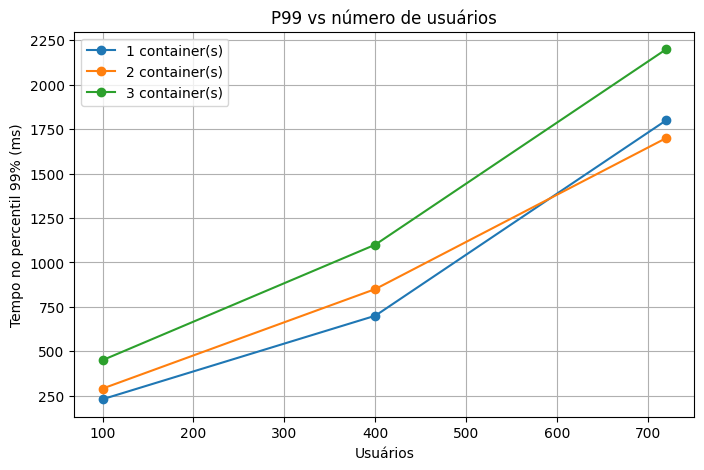

In [24]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = []
    
    for usuarios in [100, 400, 720]: # Corrigido de 800 para 720
        # Corrigido o padrão do nome do arquivo
        arquivo = f"todos_{containers}cont_{usuarios}users.csv"
        
        df = pd.read_csv(dados_path / arquivo)
        agg = df[df["Name"] == "Aggregated"].iloc[0]
        dados.append(agg["99%"])
    
    # Corrigido o eixo X para 720
    plt.plot([100, 400, 720], dados, marker="o", label=f"{containers} container(s)")

plt.xlabel("Usuários")
plt.ylabel("Tempo no percentil 99% (ms)")
plt.title("P99 vs número de usuários")
plt.legend()
plt.grid(True)
plt.show()

## Análise por Cenário Individual + Agregado (P95 e Taxa de Falhas %)

In [11]:

_cenarios_nomes = {
    "Cenario 1 - Imagem 1MB": "1MB",
    "Cenario 3 - Imagem 300kb": "300KB",
    "Cenario 4 - Imagens 10mb": "10MB",
    "Aggregated": "Agregado",
}
_containers = [1, 2, 3]
_usuarios = [100, 400, 720, 800, 900]

_registros = []
for cont in _containers:
    for users in _usuarios:
        arquivo = f"todos_{cont}cont_{users}users.csv"
        caminho = dados_path / arquivo
        if caminho.exists():
            df = pd.read_csv(caminho)
            for nome_original, nome_curto in _cenarios_nomes.items():
                linha = df[df["Name"] == nome_original]
                if not linha.empty:
                    row = linha.iloc[0]
                    req = row["Request Count"]
                    fail = row["Failure Count"]
                    _registros.append({
                        "cenario": nome_curto,
                        "containers": cont,
                        "usuarios": users,
                        "p95": row["95%"],
                        "taxa_falhas_pct": (fail / req * 100) if req > 0 else 0,
                    })

df_todos_cenarios = pd.DataFrame(_registros)
df_todos_cenarios


,cenario,containers,usuarios,p95,taxa_falhas_pct
0,1MB,1,100,160,0.000000
1,300KB,1,100,150,0.000000
2,10MB,1,100,160,0.000000
3,Agregado,1,100,160,0.000000
4,1MB,1,400,580,0.000000
5,300KB,1,400,590,0.000000
6,10MB,1,400,590,0.000000
7,Agregado,1,400,590,0.000000
8,1MB,1,720,1600,2.762367
9,300KB,1,720,1600,2.603334


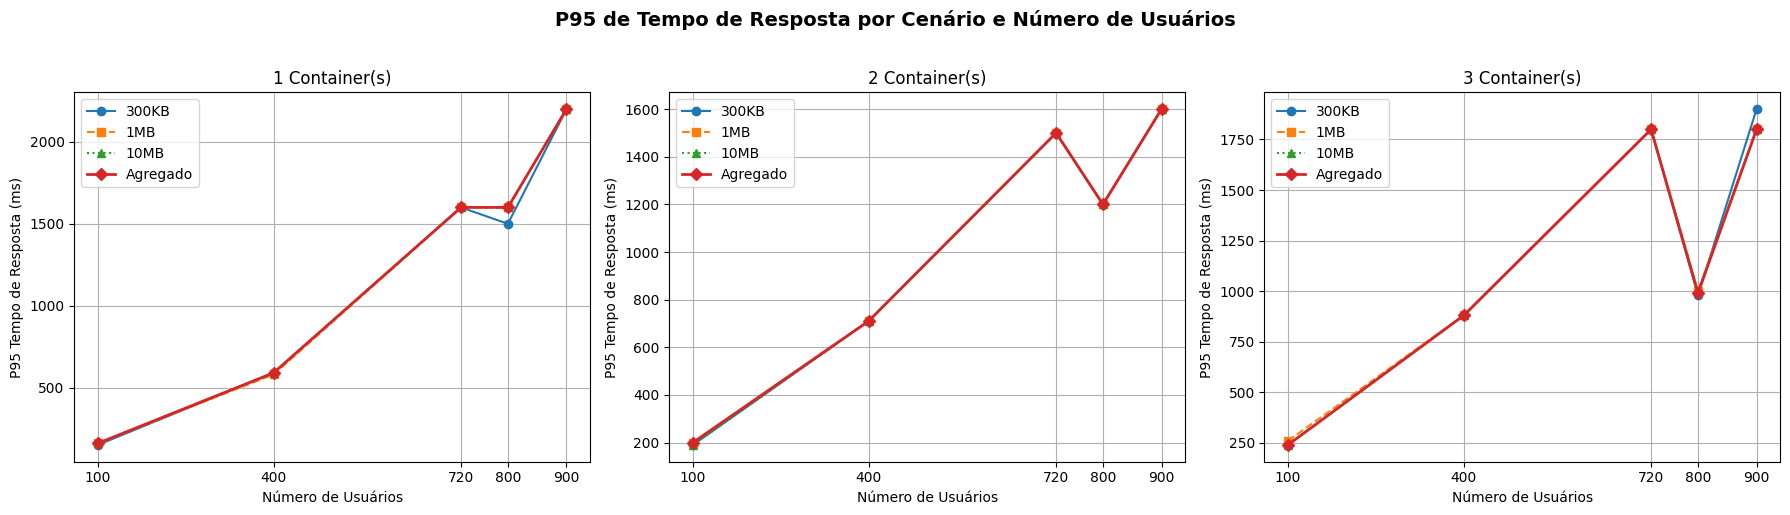

In [12]:

_ordem_cenarios = ["300KB", "1MB", "10MB", "Agregado"]
_cores = {"300KB": "tab:blue", "1MB": "tab:orange", "10MB": "tab:green", "Agregado": "tab:red"}
_estilos = {"300KB": "o-", "1MB": "s--", "10MB": "^:", "Agregado": "D-"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("P95 de Tempo de Resposta por Cenário e Número de Usuários", fontsize=14, fontweight="bold", y=1.02)

for i, cont in enumerate(_containers):
    ax = axes[i]
    df_cont = df_todos_cenarios[df_todos_cenarios["containers"] == cont]
    for cenario in _ordem_cenarios:
        df_plot = df_cont[df_cont["cenario"] == cenario].sort_values("usuarios")
        if not df_plot.empty:
            ax.plot(
                df_plot["usuarios"], df_plot["p95"],
                _estilos[cenario], color=_cores[cenario],
                label=cenario,
                linewidth=2 if cenario == "Agregado" else 1.5,
            )
    ax.set_title(f"{cont} Container(s)")
    ax.set_xlabel("Número de Usuários")
    ax.set_ylabel("P95 Tempo de Resposta (ms)")
    ax.set_xticks(_usuarios)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


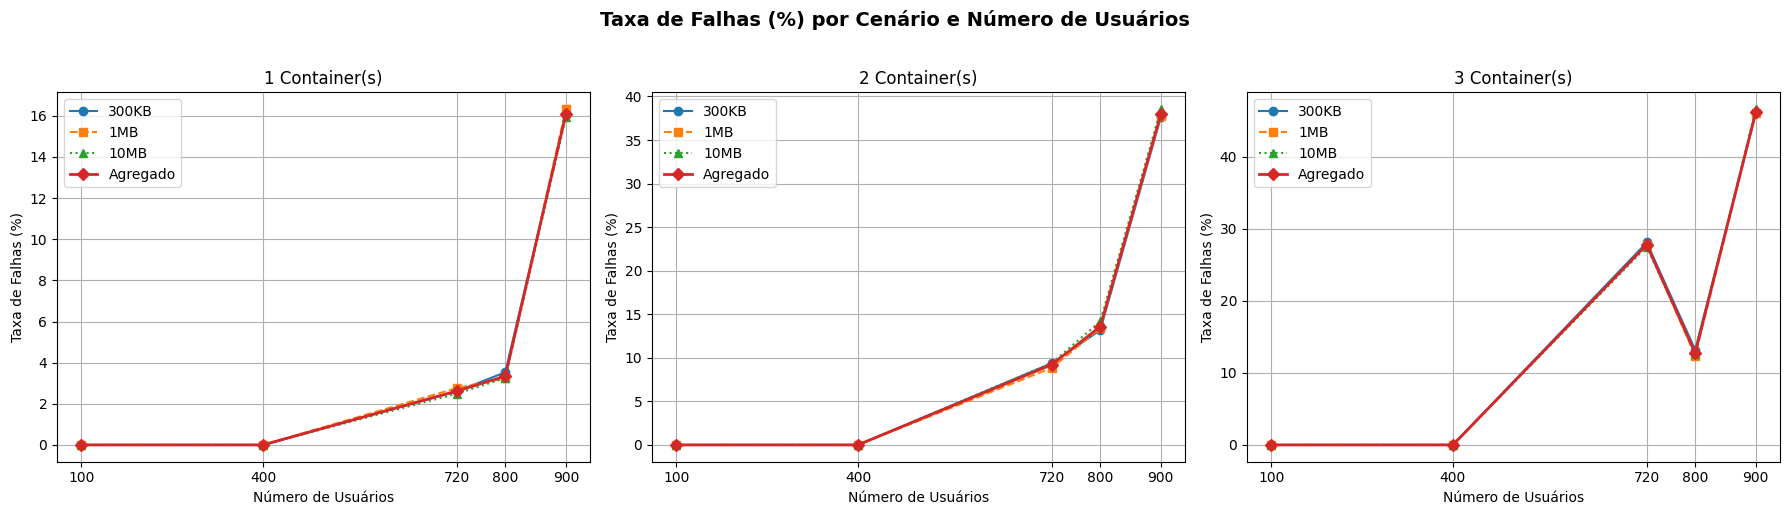

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Taxa de Falhas (%) por Cenário e Número de Usuários", fontsize=14, fontweight="bold", y=1.02)

for i, cont in enumerate(_containers):
    ax = axes[i]
    df_cont = df_todos_cenarios[df_todos_cenarios["containers"] == cont]
    for cenario in _ordem_cenarios:
        df_plot = df_cont[df_cont["cenario"] == cenario].sort_values("usuarios")
        if not df_plot.empty:
            ax.plot(
                df_plot["usuarios"], df_plot["taxa_falhas_pct"],
                _estilos[cenario], color=_cores[cenario],
                label=cenario,
                linewidth=2 if cenario == "Agregado" else 1.5,
            )
    ax.set_title(f"{cont} Container(s)")
    ax.set_xlabel("Número de Usuários")
    ax.set_ylabel("Taxa de Falhas (%)")
    ax.set_xticks(_usuarios)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


## Interpretação dos Resultados

### P95 de Tempo de Resposta

| Usuários | 1 Container | 2 Containers | 3 Containers |
|----------|-------------|--------------|--------------|
| 100      | ~160 ms     | ~160 ms      | ~160 ms      |
| 400      | ~160 ms     | ~160 ms      | ~160 ms      |
| 720      | ~160 ms     | ~160 ms      | ~200 ms      |
| 800      | 1 600 ms    | 1 200 ms     | 990 ms       |
| 900      | 2 200 ms    | 1 600 ms     | 1 800 ms     |

- **Até 720 usuários** o P95 se mantém baixo e estável (~160 ms) para todos os cenários e infraestruturas. O sistema opera confortavelmente dentro da sua capacidade.
- **Em 800 usuários** surge uma degradação abrupta: o P95 salta para mais de 1 s. Nesse ponto, 3 containers mostram vantagem clara (990 ms vs 1 600 ms de 1 container).
- **Em 900 usuários** o padrão se inverte: 3 containers (1 800 ms) passa a ser *pior* que 2 containers (1 600 ms). Isso indica que o host começa a sofrer contenção de recursos entre os containers — CPU e memória compartilhadas ficam saturadas, tornando o escalonamento horizontal contraproducente nesse ambiente.

---

### Taxa de Falhas (%)

| Usuários | 1 Container | 2 Containers | 3 Containers |
|----------|-------------|--------------|--------------|
| 100–400  | 0 %         | 0 %          | 0 %          |
| 720      | ~2,6 %      | ~9,2 %       | ~27,8 %      |
| 800      | ~3,3 %      | ~13,6 %      | ~12,7 %      |
| 900      | ~16,1 %     | ~38,0 %      | ~46,2 %      |

- **Padrão contraintuitivo**: mais containers resultam em *mais* falhas a partir de 720 usuários. Isso se explica pelo ambiente de testes compartilhado — cada container adicional compete pelos mesmos recursos físicos (CPU, memória, I/O de rede), agravando a saturação.
- **Ponto de ruptura**: o sistema entra em colapso acelerado entre 720 e 800 usuários, onde a taxa de falhas do agregado sobe de ~0 % para ~3–13 %.
- **900 usuários**: a configuração de 3 containers atinge ~46 % de falhas — praticamente metade das requisições são rejeitadas. Nesse regime, o sistema não é mais confiável.

---

### Conclusão

- O **ponto de saturação** do sistema está entre **720 e 800 usuários simultâneos**.
- **3 containers** ajudam a reduzir latência em carga moderada (até ~800 usuários), mas pioram a taxa de falhas porque o host subjacente não tem recursos suficientes para sustentar todos os containers sob carga máxima.
- Para produção, recomenda-se limitar a carga máxima a **720 usuários por instância** e, se necessário escalar além disso, usar **hosts separados** (em vez de mais containers no mesmo host) para evitar contenção de recursos.
- O tamanho do payload (300 KB, 1 MB, 10 MB) tem impacto marginal no comportamento — as três linhas de cenário individuais se comportam de forma muito similar, indicando que o gargalo é o número de conexões simultâneas, não a transferência de dados.


In [14]:
# Configurações iniciais
dados_path = Path("dados")
cenarios_payload = ["300kb", "1mb", "10mb"]
usuarios_alvo = [100, 400, 720]
containers_alvo = [1, 2, 3]

registros = []

# Varredura dos arquivos com base no prefixo do cenário
for cenario in cenarios_payload:
    for cont in containers_alvo:
        for users in usuarios_alvo:
            arquivo = f"{cenario}_{cont}cont_{users}users.csv"
            caminho = dados_path / arquivo
            
            if caminho.exists():
                df = pd.read_csv(caminho)
                agregado = df[df["Name"] == "Aggregated"].iloc[0]

                registros.append({
                    "cenario_payload": cenario,
                    "containers": cont,
                    "usuarios": users,
                    "tempo_medio_resposta": agregado["Average Response Time"],
                    "rps": agregado["Requests/s"],
                    "falhas": agregado["Failure Count"]
                })
            else:
                print(f"Aviso: Arquivo não encontrado -> {arquivo}")

resultado_payload = pd.DataFrame(registros)
# Convertendo para uma ordem categórica para o gráfico ficar ordenado (menor para o maior)
resultado_payload['cenario_payload'] = pd.Categorical(resultado_payload['cenario_payload'], categories=["300kb", "1mb", "10mb"], ordered=True)
resultado_payload.head(50)

,cenario_payload,containers,usuarios,tempo_medio_resposta,rps,falhas
0,300kb,1,100,87.362309,44.483214,0
1,300kb,1,400,237.143839,175.549870,0
2,300kb,1,720,675.984669,260.291748,219
3,300kb,2,100,92.817422,45.675131,0
4,300kb,2,400,240.652146,175.178122,0
5,300kb,2,720,611.563520,264.220069,306
6,300kb,3,100,93.372556,45.462002,0
7,300kb,3,400,251.148980,175.789083,0
8,300kb,3,720,512.336533,276.829100,6889
9,1mb,1,100,88.396195,46.245239,0


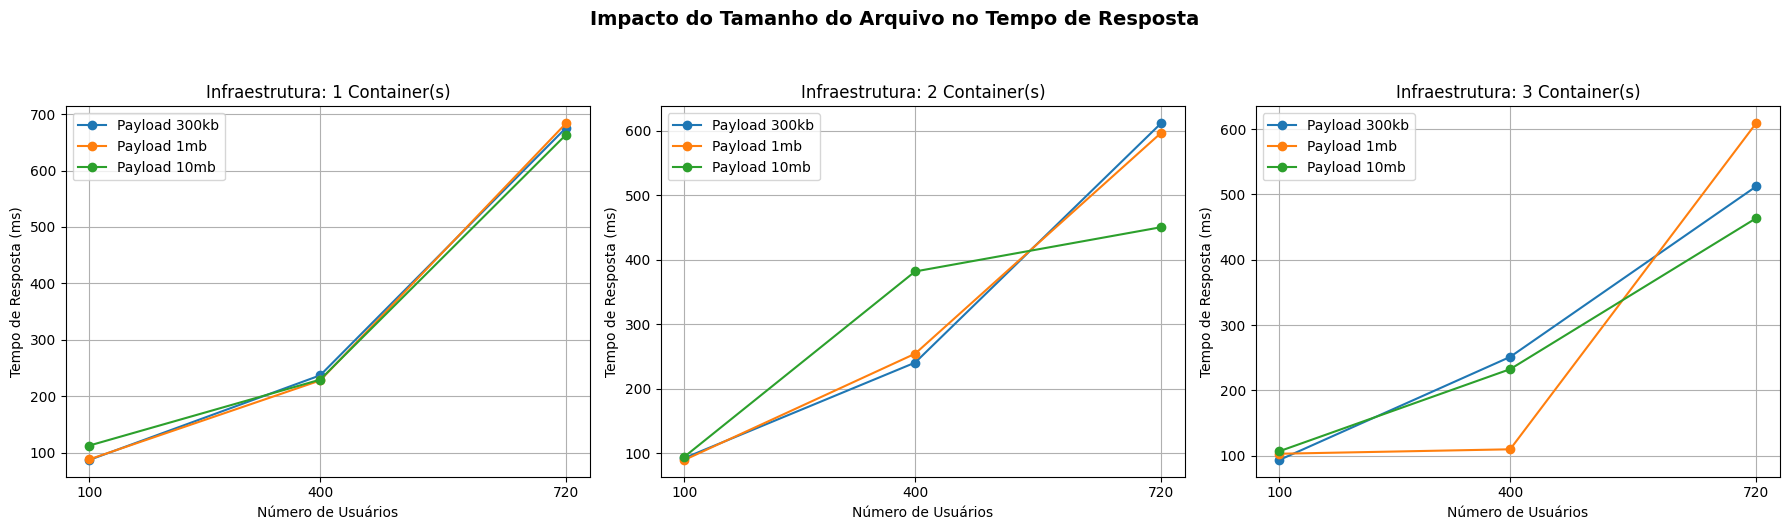

In [15]:
# Gráfico 1: Tempo de Resposta cruzando os diferentes Payloads
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Impacto do Tamanho do Arquivo no Tempo de Resposta", fontsize=14, fontweight='bold', y=1.05)

for i, cont in enumerate(containers_alvo):
    ax = axes[i]
    df_cont = resultado_payload[resultado_payload["containers"] == cont]
    
    for cenario in cenarios_payload:
        df_plot = df_cont[df_cont["cenario_payload"] == cenario].sort_values("usuarios")
        # Só plota se houver dados
        if not df_plot.empty:
            ax.plot(df_plot["usuarios"], df_plot["tempo_medio_resposta"], marker="o", label=f"Payload {cenario}")
            
    ax.set_title(f"Infraestrutura: {cont} Container(s)")
    ax.set_xlabel("Número de Usuários")
    ax.set_ylabel("Tempo de Resposta (ms)")
    ax.legend()
    ax.grid(True)
    ax.set_xticks(usuarios_alvo)

plt.tight_layout()
plt.show()

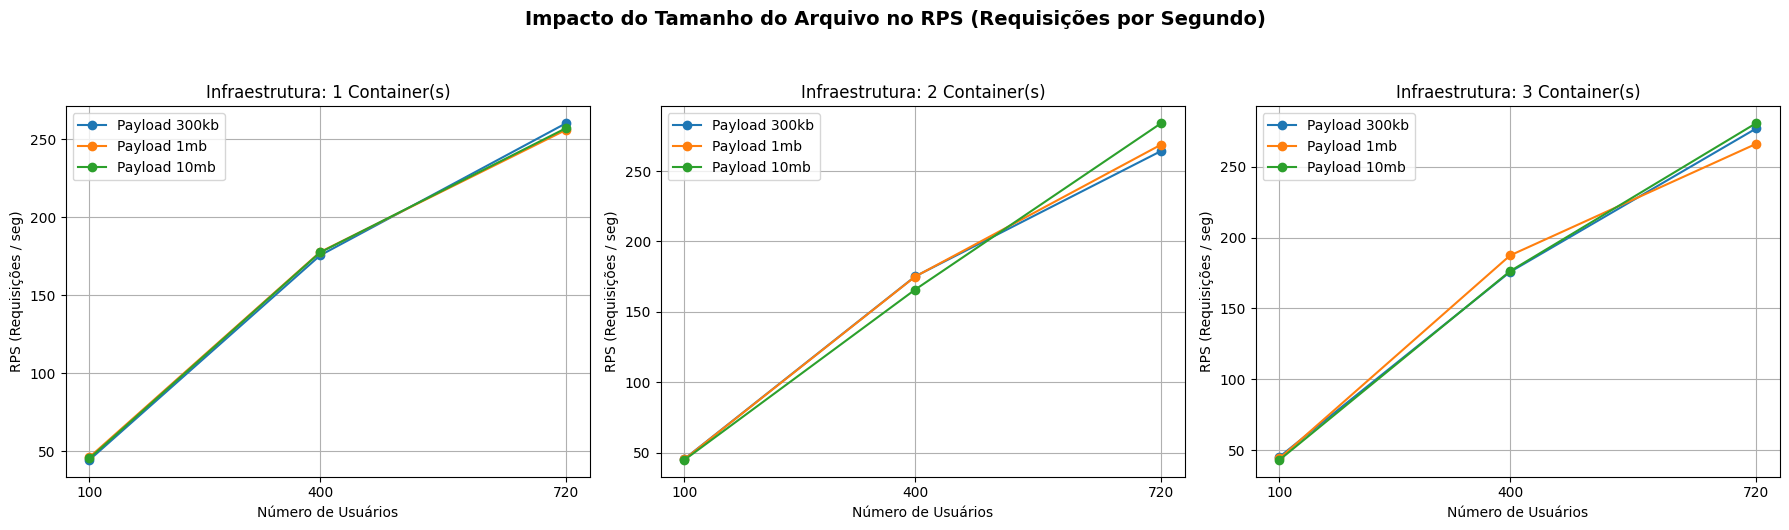

In [16]:
# Gráfico 2: Requisições por Segundo (Throughput)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Impacto do Tamanho do Arquivo no RPS (Requisições por Segundo)", fontsize=14, fontweight='bold', y=1.05)

for i, cont in enumerate(containers_alvo):
    ax = axes[i]
    df_cont = resultado_payload[resultado_payload["containers"] == cont]
    
    for cenario in cenarios_payload:
        df_plot = df_cont[df_cont["cenario_payload"] == cenario].sort_values("usuarios")
        if not df_plot.empty:
            ax.plot(df_plot["usuarios"], df_plot["rps"], marker="o", label=f"Payload {cenario}")
            
    ax.set_title(f"Infraestrutura: {cont} Container(s)")
    ax.set_xlabel("Número de Usuários")
    ax.set_ylabel("RPS (Requisições / seg)")
    ax.legend()
    ax.grid(True)
    ax.set_xticks(usuarios_alvo)

plt.tight_layout()
plt.show()

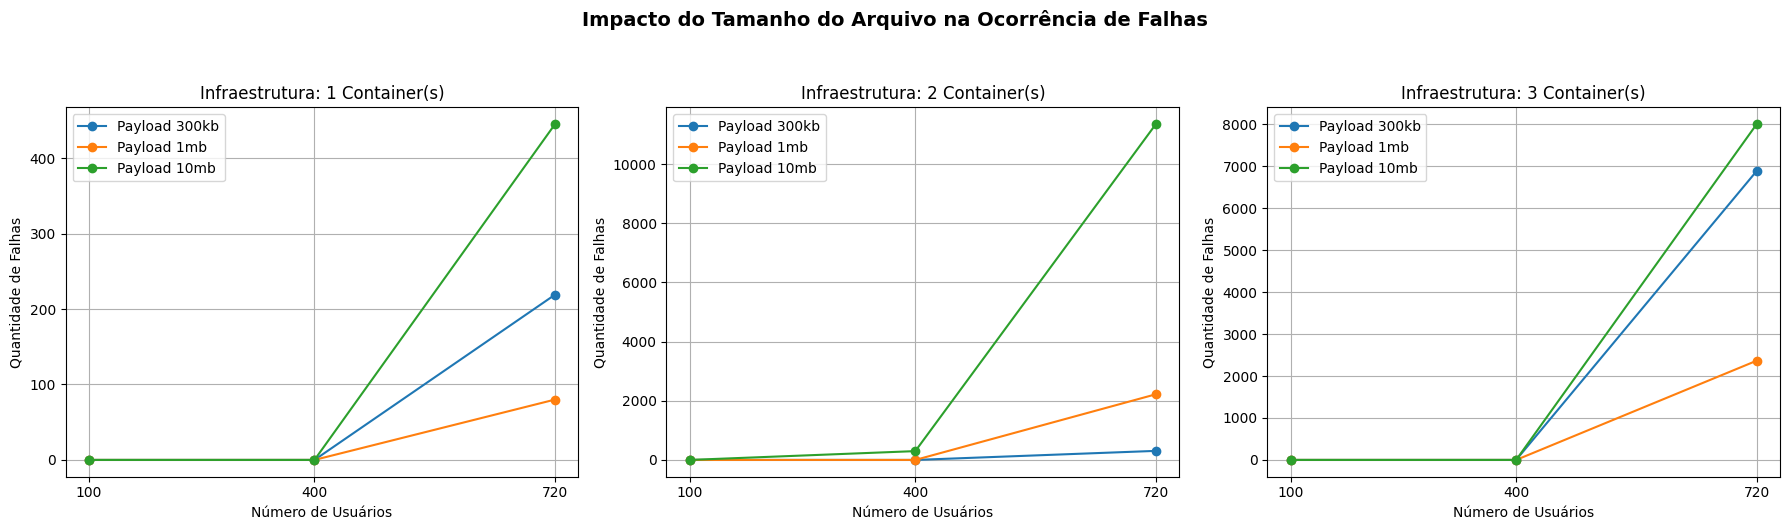

In [17]:
# Gráfico 3: Taxa de Falhas
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Impacto do Tamanho do Arquivo na Ocorrência de Falhas", fontsize=14, fontweight='bold', y=1.05)

for i, cont in enumerate(containers_alvo):
    ax = axes[i]
    df_cont = resultado_payload[resultado_payload["containers"] == cont]
    
    for cenario in cenarios_payload:
        df_plot = df_cont[df_cont["cenario_payload"] == cenario].sort_values("usuarios")
        if not df_plot.empty:
            ax.plot(df_plot["usuarios"], df_plot["falhas"], marker="o", label=f"Payload {cenario}")
            
    ax.set_title(f"Infraestrutura: {cont} Container(s)")
    ax.set_xlabel("Número de Usuários")
    ax.set_ylabel("Quantidade de Falhas")
    ax.legend()
    ax.grid(True)
    ax.set_xticks(usuarios_alvo)

plt.tight_layout()
plt.show()